In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BankChurners.csv to BankChurners.csv


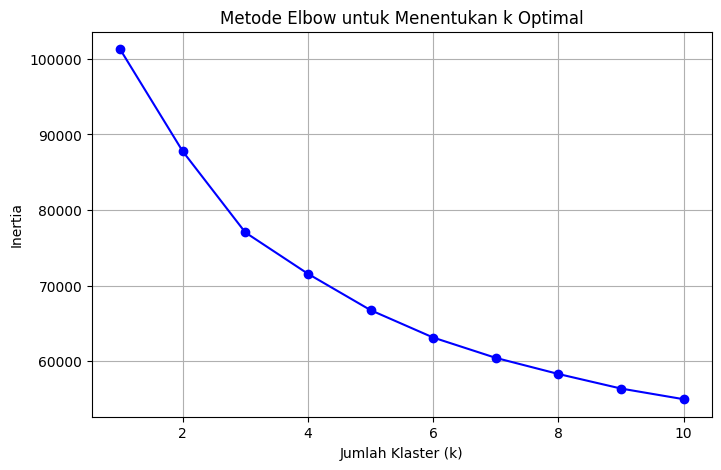

Silhouette Score (K-Means): 0.1193311814465096


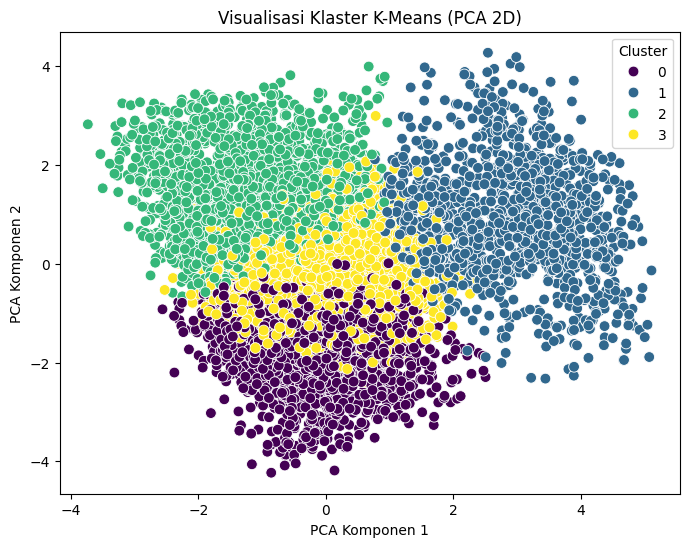

                Customer_Age  Dependent_count  Months_on_book  \
Cluster_KMeans                                                  
0                  37.569092         1.886754       27.996321   
1                  45.551387         2.367863       35.287113   
2                  55.090494         1.368821       43.628137   
3                  46.147712         3.305098       35.912157   

                Total_Relationship_Count  Months_Inactive_12_mon  \
Cluster_KMeans                                                     
0                               4.289861                2.182747   
1                               2.117455                2.195759   
2                               4.129658                2.426616   
3                               3.832680                2.430327   

                Contacts_Count_12_mon  Credit_Limit  Total_Revolving_Bal  \
Cluster_KMeans                                                             
0                            2.890842   7067.742

In [ ]:
# 1. Import Library
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv('BankChurners.csv')

# 3. Drop kolom yang tidak relevan (ID & target label)
df = df.drop(['CLIENTNUM', 'Attrition_Flag'], axis=1)

# 4. Pilih 10 fitur yang relevan
selected_features = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Trans_Amt', 'Total_Trans_Ct'
]

# Pilih data berdasarkan fitur yang telah dipilih
df_selected = df[selected_features]

# 5. One-hot encoding kolom kategorikal (jika ada)
df_selected = pd.get_dummies(df_selected, drop_first=True)

# 6. Normalisasi fitur numerik
scaler = StandardScaler()
scaled_selected = scaler.fit_transform(df_selected)

# 7. Tentukan jumlah klaster optimal dengan Elbow Method (untuk referensi, bisa dilewati jika sudah pilih k)
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_selected)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k Optimal')
plt.grid(True)
plt.show()

# 8. Terapkan K-Means (misalnya setelah elbow, kita pilih k=4)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_selected)

# 9. Tambahkan label klaster ke data
df_selected['Cluster_KMeans'] = kmeans_labels

# 10. Evaluasi dengan Silhouette Score
score = silhouette_score(scaled_selected, kmeans_labels)
print("Silhouette Score (K-Means):", score)

# 11. Visualisasi hasil clustering dengan PCA (dimensi 2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_selected)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=kmeans_labels, palette='viridis', s=60)
plt.title('Visualisasi Klaster K-Means (PCA 2D)')
plt.xlabel('PCA Komponen 1')
plt.ylabel('PCA Komponen 2')
plt.legend(title='Cluster')
plt.show()

# 12. Cek rata-rata nilai fitur dalam tiap klaster
cluster_means = df_selected.groupby('Cluster_KMeans').mean()
print(cluster_means)


Jumlah klaster DBSCAN: 1
Jumlah noise (outliers): 10123


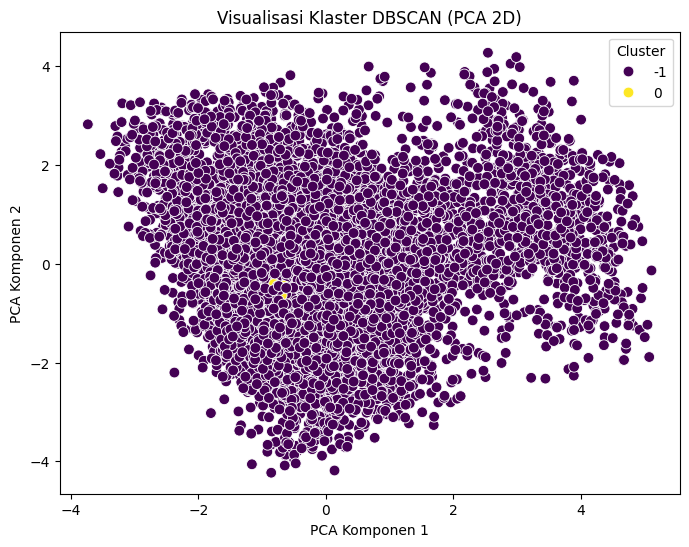

                Customer_Age  Dependent_count  Months_on_book  \
Cluster_DBSCAN                                                  
0                      43.75              3.0           35.75   

                Total_Relationship_Count  Months_Inactive_12_mon  \
Cluster_DBSCAN                                                     
0                                    2.0                     3.0   

                Contacts_Count_12_mon  Credit_Limit  Total_Revolving_Bal  \
Cluster_DBSCAN                                                             
0                                 3.0      1879.325                  0.0   

                Total_Trans_Amt  Total_Trans_Ct  
Cluster_DBSCAN                                   
0                       2253.75           41.75  


In [ ]:
# 1. Import Library DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 2. Load Dataset (Assuming the dataset has been preprocessed and selected features)
df = pd.read_csv('BankChurners.csv')

# 3. Pilih 10 fitur yang relevan
selected_features = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Trans_Amt', 'Total_Trans_Ct'
]

# Pilih data berdasarkan fitur yang telah dipilih
df_selected = df[selected_features]

# 4. One-hot encoding kolom kategorikal (jika ada)
df_selected = pd.get_dummies(df_selected, drop_first=True)

# 5. Normalisasi fitur numerik
scaler = StandardScaler()
scaled_selected = scaler.fit_transform(df_selected)

# 6. Terapkan DBSCAN dengan parameter yang disesuaikan
dbscan = DBSCAN(eps=0.5, min_samples=4)  # Ganti nilai eps dan min_samples
dbscan_labels = dbscan.fit_predict(scaled_selected)

# 7. Tambahkan label DBSCAN ke dataframe
df_selected['Cluster_DBSCAN'] = dbscan_labels

# 8. Evaluasi Hasil:
# - Menghitung jumlah klaster yang terbentuk
# - Menghitung jumlah noise (outliers) yang memiliki label -1
unique_labels = np.unique(dbscan_labels)
print(f"Jumlah klaster DBSCAN: {len(unique_labels) - 1}")  # Mengurangi 1 karena noise diberi label -1
print(f"Jumlah noise (outliers): {(dbscan_labels == -1).sum()}")

# 9. Visualisasi Hasil DBSCAN dengan PCA (dimensi 2D)
# Menggunakan PCA untuk mereduksi data ke dimensi 2D untuk visualisasi
pca = PCA(n_components=2)
pca_result_dbscan = pca.fit_transform(scaled_selected)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result_dbscan[:, 0], y=pca_result_dbscan[:, 1],
                hue=dbscan_labels, palette='viridis', s=60, marker='o')
plt.title('Visualisasi Klaster DBSCAN (PCA 2D)')
plt.xlabel('PCA Komponen 1')
plt.ylabel('PCA Komponen 2')
plt.legend(title='Cluster')
plt.show()

# 10. Cek rata-rata nilai fitur dalam tiap klaster (untuk klaster yang bukan noise)
cluster_means_dbscan = df_selected[df_selected['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN').mean()
print(cluster_means_dbscan)


Jumlah klaster KMeans: 5
Jumlah klaster DBSCAN: 1
Jumlah noise (outliers) DBSCAN: 10123


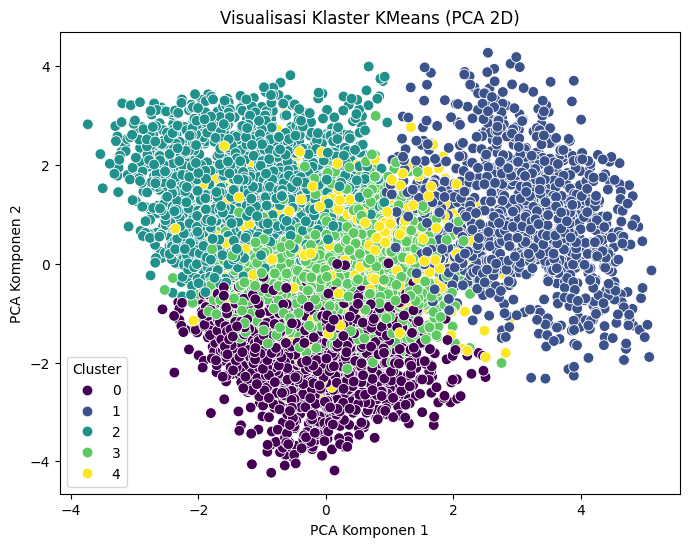

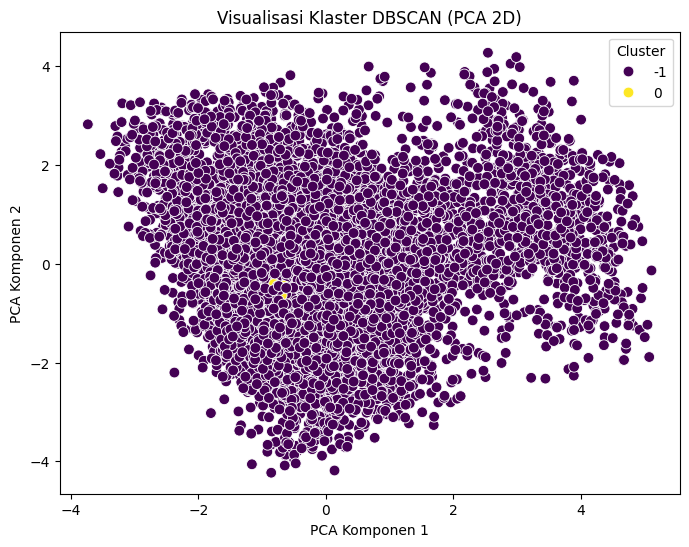

Rata-rata fitur dalam tiap klaster KMeans:
                Customer_Age  Dependent_count  Months_on_book  \
Cluster_KMeans                                                  
0                  37.295126         1.858303       27.695848   
1                  45.387037         2.312037       35.172222   
2                  55.460583         1.330763       43.951157   
3                  46.141888         3.250442       35.944543   
4                  46.624210         2.728094       36.181572   

                Total_Relationship_Count  Months_Inactive_12_mon  \
Cluster_KMeans                                                     
0                               4.361462                2.186372   
1                               2.128704                2.187963   
2                               4.151671                2.426735   
3                               3.677876                2.435988   
4                               4.054201                2.329720   

                Contacts

In [ ]:
# Evaluasi hasil K-Means dengan DBSCAN
# 1. Import library yang dibutuhkan
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load Dataset (Asumsi dataset sudah diproses dan memilih fitur)
df = pd.read_csv('BankChurners.csv')

# 3. Pilih 10 fitur yang relevan
selected_features = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Trans_Amt', 'Total_Trans_Ct'
]

# Pilih data berdasarkan fitur yang telah dipilih
df_selected = df[selected_features]

# 4. One-hot encoding kolom kategorikal (jika ada)
df_selected = pd.get_dummies(df_selected, drop_first=True)

# 5. Normalisasi fitur numerik
scaler = StandardScaler()
scaled_selected = scaler.fit_transform(df_selected)

# 6. Terapkan KMeans dengan n_clusters = 5
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_selected)

# 7. Terapkan DBSCAN dengan parameter yang disesuaikan
dbscan = DBSCAN(eps=0.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(scaled_selected)

# 8. Tambahkan label klaster ke dataframe
df_selected['Cluster_KMeans'] = kmeans_labels
df_selected['Cluster_DBSCAN'] = dbscan_labels

# 9. Evaluasi hasil:
# - Menghitung jumlah klaster yang terbentuk
# - Menghitung jumlah noise (outliers) yang memiliki label -1 (untuk DBSCAN)

# KMeans: Jumlah klaster
print(f"Jumlah klaster KMeans: {len(np.unique(kmeans_labels))}")

# DBSCAN: Jumlah klaster dan noise
unique_dbscan_labels = np.unique(dbscan_labels)
print(f"Jumlah klaster DBSCAN: {len(unique_dbscan_labels) - 1}")  # Mengurangi 1 karena noise diberi label -1
print(f"Jumlah noise (outliers) DBSCAN: {(dbscan_labels == -1).sum()}")

# 10. Visualisasi Hasil KMeans dengan PCA (dimensi 2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_selected)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=kmeans_labels, palette='viridis', s=60, marker='o')
plt.title('Visualisasi Klaster KMeans (PCA 2D)')
plt.xlabel('PCA Komponen 1')
plt.ylabel('PCA Komponen 2')
plt.legend(title='Cluster')
plt.show()

# 11. Visualisasi Hasil DBSCAN dengan PCA (dimensi 2D)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=dbscan_labels, palette='viridis', s=60, marker='o')
plt.title('Visualisasi Klaster DBSCAN (PCA 2D)')
plt.xlabel('PCA Komponen 1')
plt.ylabel('PCA Komponen 2')
plt.legend(title='Cluster')
plt.show()

# 12. Rata-rata fitur dalam setiap klaster (untuk klaster yang bukan noise)
# KMeans: Rata-rata fitur dalam setiap klaster
kmeans_means = df_selected.groupby('Cluster_KMeans').mean()
print("Rata-rata fitur dalam tiap klaster KMeans:")
print(kmeans_means)

# DBSCAN: Rata-rata fitur dalam setiap klaster (mengabaikan noise)
dbscan_means = df_selected[df_selected['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN').mean()
print("Rata-rata fitur dalam tiap klaster DBSCAN:")
print(dbscan_means)

# 13. Evaluasi dengan Silhouette Score
# Silhouette Score untuk KMeans
kmeans_score = silhouette_score(scaled_selected, kmeans_labels)
print(f"Silhouette Score KMeans: {kmeans_score}")

# Silhouette Score untuk DBSCAN (hanya untuk klaster yang bukan noise)
if len(np.unique(dbscan_labels)) > 1:  # Pastikan ada klaster yang terbentuk
    dbscan_score = silhouette_score(scaled_selected, dbscan_labels)
else:
    dbscan_score = -1  # Jika hanya ada noise, beri nilai -1
print(f"Silhouette Score DBSCAN: {dbscan_score}")
